In [1]:
import matplotlib.pyplot as plt

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})


In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from utils.preprocess_behavior import *
from utils.preprocess_thorsync import *
from utils.preprocess_neural import *

import matplotlib.pyplot as plt
import matplotlib.cm as cm

import numpy.ma as ma
from scipy.ndimage import gaussian_filter
from tqdm import tqdm
import subprocess

%matplotlib widget

# Good Sessions CKII:
[pAce21/2025-08-06_pAce21_PR/Awake](/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce21/2025-08-06_pAce21_PR/Awake)

[pAce38/2025-11-26_pAce38/PX/post/Awake](/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake)

[pAce37/2025-11-12_pAce37_BR/post/Awake](/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce37/2025-11-12_pAce37_BR/post/Awake)


In [ ]:
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce21/2025-06-30_pAce21_PR/Awake'
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce9/2025-02-10_pAce9-PX/post-cement/awake/fov1'
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce37/2025-11-12_pAce37_BR/post/Awake' # Finished
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce19/2025-04-21_pAce19/PX/Awake/FOV1' # problem with behavior

#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce17/2025-03-26_pAce17/PX/short-lens/post-cement/Awake' # Good
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce28/2025-08-11-pAce28/Awake'

#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake' # Good
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce45/2026-01-18_pAce45/PX/post/Awake'
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake' # Good
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce21/2025-08-06_pAce21_PR/Awake' # Good
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake'
main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce50/2026-03-17_pAce50_PRL/Awake'

######## Interneurons ########
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce17/2025-03-26_pAce17/PX/short-lens/post-cement/Awake'  # WT
#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce9/2025-02-10_pAce9-PX/post-cement/awake/fov1' # SST INs

#main_data_folder = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce9/2025-02-13_pAce9_WX/Awake' # SST INs


subfolders = [os.path.join(main_data_folder, f) for f in os.listdir(main_data_folder) if os.path.isdir(os.path.join(main_data_folder, f)) and f.endswith('-good')]
subfolders.sort()
print(subfolders)

['/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce50/2025-03-17_pAce50_PRL/Awake/2-good']


In [4]:
# --- Concatenated demix support (optional) ---
USE_CONCAT_DEMIX = True

concat_root = os.path.join(main_data_folder, 'output_concat')
concat_manifest_path = os.path.join(concat_root, 'concat_raw_manifest.json')

demix_by_session = None
frames_truncated = 500  # default (used for thorsync alignment)

if USE_CONCAT_DEMIX:
    import glob

    manifest = load_concat_raw_manifest(concat_manifest_path)
    frames_truncated = int(manifest.get('frames_to_truncate_per_session', 500))
    session_edges_frames = manifest.get('session_edges_frames', None)

    # Prefer annotated results if present
    candidates = []
    candidates += glob.glob(os.path.join(concat_root, 'output_final', '*', 'volpy_demix_results_annotated.pickle'))
    candidates += glob.glob(os.path.join(concat_root, 'output_final', '*', 'volpy_demix_results.pickle'))
    candidates += glob.glob(os.path.join(concat_root, 'volpy_demix_results_annotated.pickle'))
    candidates += glob.glob(os.path.join(concat_root, 'volpy_demix_results.pickle'))

    if not candidates:
        raise FileNotFoundError(f'No volpy demix results found under: {concat_root}')

    concat_demix_path = candidates[0]
    print('Using concatenated demix:', concat_demix_path)

    with open(concat_demix_path, 'rb') as f:
        concat_results = pickle.load(f)

    split_sessions = split_concatenated_volpy_results(
        concat_results,
        session_edges_frames,
        frame_rate_hz=manifest.get('frame_rate_hz', None),
    )

    session_folders_manifest = [s.get('session_good_folder_local', '') for s in manifest.get('sessions_local', [])]
    if any([not p for p in session_folders_manifest]) or len(session_folders_manifest) != len(split_sessions):
        print('[WARN] Could not map manifest sessions to -good folders; falling back to subfolders order.')
        session_folders_manifest = list(subfolders)[:len(split_sessions)]

    demix_by_session = {sf: d for sf, d in zip(session_folders_manifest, split_sessions)}

    # Ensure subfolders follow concatenation order (important for later merging)
    subfolders = [sf for sf in session_folders_manifest if sf in subfolders] + [sf for sf in subfolders if sf not in session_folders_manifest]

    print('Using subfolders order:', subfolders)
    print('frames_truncated:', frames_truncated)


Using concatenated demix: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce50/2025-03-17_pAce50_PRL/Awake/output_concat/output_final/concat_mc/volpy_demix_results_annotated.pickle
Using subfolders order: ['/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce50/2025-03-17_pAce50_PRL/Awake/2-good']
frames_truncated: 500


# Behavior refinement

### Run the next 2 cells if you haven't draw a rectangle ROI yet

Processing folder: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce50/2025-03-17_pAce50_PRL/Awake/2-good
Video dimensions: 1404x884, FPS: 20.0, Total frames: 24020
pixel to cm ratio=39.55 (width), 44.20 (height)
Using filtered DLC file: Flir-03172026134025-0000DLC_Resnet50_TopViewMouse_MidlineDec11shuffle1_snapshot_080_filtered.csv
Frames with no valid best position: 132/24020 (0.5%)
Frames with no valid second position: 552/24020 (2.3%)


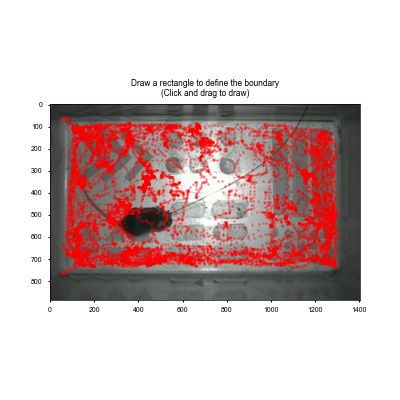

In [5]:
# Behavior refinement
width_real = 35.5  # cm
height_real = 20  # cm
frames = []
x_all = []
y_all = []
for data_folder in subfolders:
    print(f"Processing folder: {data_folder}")
    frame_width, frame_height, ratio_width, ratio_height, video_fps, video_n_frames, frame_rgb = get_behav_video_dimensions(data_folder, width_real, height_real, sample_frame_idx=100)
    frames.append(frame_rgb)
    df = read_DLC_csv_file(data_folder)
    df_refined = refine_headpositions(df, thr_likelihood_head=0.5, thr_likelihood_nose=0.5, filter_kernel_size=3)
    x_all.append(df_refined['head_best_x'].to_numpy())
    y_all.append(df_refined['head_best_y'].to_numpy())

frames = np.array(frames)
x_all = np.concatenate(x_all, axis=0)
y_all = np.concatenate(y_all, axis=0)

# Interactive rectangle drawing tool
from matplotlib.widgets import RectangleSelector
import matplotlib.patches as patches

class BoundarySelector:
    def __init__(self, frame, x_all, y_all):
        self.frame = frame
        self.x_all = x_all
        self.y_all = y_all
        self.rect_coords = None  # (x1, y1, x2, y2)
        
        self.fig, self.ax = plt.subplots(figsize=(4,4))
        self.ax.imshow(frame)
        self.scatter = self.ax.scatter(x_all, y_all, s=1, c='red', alpha=0.3)
        self.ax.set_title('Draw a rectangle to define the boundary\n(Click and drag to draw)')
        
        self.rect_selector = RectangleSelector(
            self.ax, self.on_select,
            useblit=True,
            button=[1],  # Left mouse button
            minspanx=5, minspany=5,
            spancoords='pixels',
            interactive=True
        )
        plt.show()
    
    def on_select(self, eclick, erelease):
        x1, y1 = eclick.xdata, eclick.ydata
        x2, y2 = erelease.xdata, erelease.ydata
        self.rect_coords = (min(x1, x2), min(y1, y2), max(x1, x2), max(y1, y2))
        print(f"Selected boundary: x=[{self.rect_coords[0]:.1f}, {self.rect_coords[2]:.1f}], "
              f"y=[{self.rect_coords[1]:.1f}, {self.rect_coords[3]:.1f}]")

# Use the mean frame for drawing
mean_frame = np.mean(frames, axis=0).astype(np.uint8)

# Create the interactive selector
%matplotlib widget
selector = BoundarySelector(mean_frame, x_all, y_all)

In [6]:
if selector.rect_coords is not None:
    x_min, y_min, x_max, y_max = selector.rect_coords
    print(f"Using drawn boundary: x=[{x_min:.1f}, {x_max:.1f}], y=[{y_min:.1f}, {y_max:.1f}]")
else:
    # Manual fallback - adjust these values based on your video
    x_min, y_min, x_max, y_max = 50, 50, 600, 400  # Example values
    print(f"Using manual boundary: x=[{x_min:.1f}, {x_max:.1f}], y=[{y_min:.1f}, {y_max:.1f}]")

boundary_box = (x_min, y_min, x_max, y_max)

import json
# Save boundary_box in each subfolder for downstream steps
boundary_path = "boundary_box.json"
for folder in subfolders:
    save_path = os.path.join(folder, boundary_path)
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump({"boundary_box": boundary_box}, f)
    print(f"Saved boundary_box to {save_path}")

Using drawn boundary: x=[53.6, 1312.1], y=[67.7, 751.8]
Saved boundary_box to /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce50/2025-03-17_pAce50_PRL/Awake/2-good/boundary_box.json


# Process all good subfolders to align neural and behavior data

Loaded GUI CS data from /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce50/2025-03-17_pAce50_PRL/Awake/merged_neural_CS.pkl
Video dimensions: 1404x884, FPS: 20.0, Total frames: 24020
pixel to cm ratio=39.55 (width), 44.20 (height)
Using filtered DLC file: Flir-03172026134025-0000DLC_Resnet50_TopViewMouse_MidlineDec11shuffle1_snapshot_080_filtered.csv
Frames with no valid best position: 463/24020 (1.9%)
Frames with no valid second position: 1332/24020 (5.5%)
Total FLIR frames detected: 24039
Total FrameOut2 peaks detected: 600010
Original traces shape: (599500, 15)
Traces shape: (9, 599500)
Spikes shape: (9,)


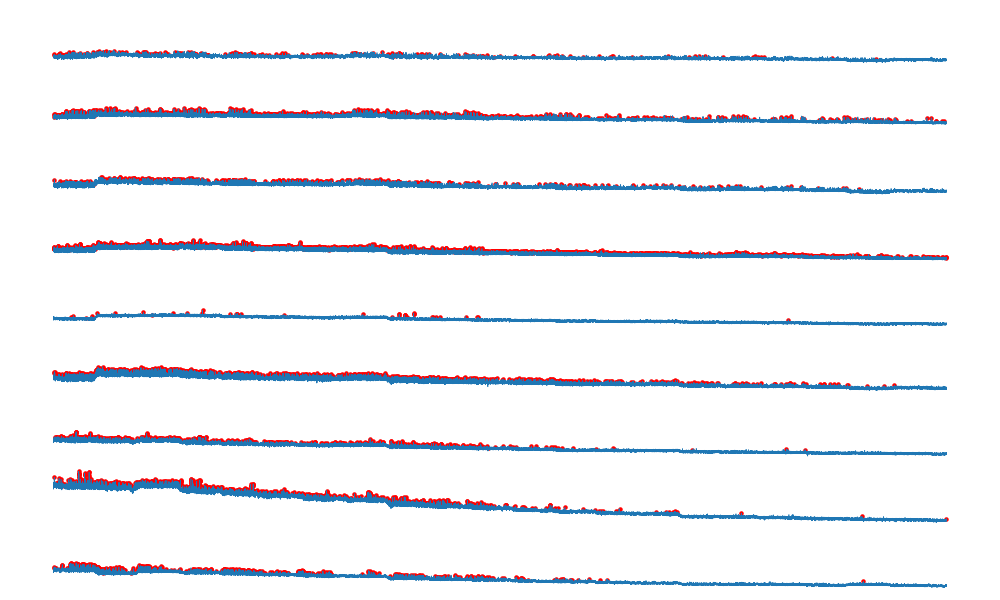

ts_behav length is now 24020 and starts at 1804.13 ms, ends at 1202754.13 ms
Neural data ends at 1203579.17 ms, behavior data ends at 1202754.13 ms
There are 825.03 ms of neural data without the behaviral data at the end.
Neural data truncated from 599500 to 599087 frames.
Aligned data saved to /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce50/2025-03-17_pAce50_PRL/Awake/2-good/aligned_data.pkl


In [8]:
import pickle

width_real = 35.5  # cm
height_real = 20  # cm

cs_data_path = os.path.join(main_data_folder, 'merged_neural_CS.pkl')
cs_data = None
cs_payloads_by_folder = {}
cs_payloads_by_basename = {}
cs_payloads_by_index = []

if os.path.exists(cs_data_path):
    with open(cs_data_path, 'rb') as f:
        cs_data = pickle.load(f)
    print(f"Loaded GUI CS data from {cs_data_path}")
else:
    print(f"[WARN] GUI CS data not found at {cs_data_path}; alignment will proceed without CS fields.")


def _normalize_per_cell(data, n_cells):
    if data is None:
        return [None] * int(n_cells)
    seq = list(data)
    if len(seq) < n_cells:
        seq = seq + [None] * (int(n_cells) - len(seq))
    elif len(seq) > n_cells:
        seq = seq[:int(n_cells)]
    return seq


def _infer_cs_total_frames(cs_dict):
    traces_cs = cs_dict.get('traces', None)
    if traces_cs is not None:
        arr = np.asarray(traces_cs)
        if arr.ndim == 2:
            return int(arr.shape[1])
    for key in ['spike_heights_interpolated', 'SNR_interpolated', 'traces_SNR_interpolated', 'Vm_SNR_interpolated']:
        seq = cs_dict.get(key, None)
        if seq is None:
            continue
        for v in list(seq):
            if v is None:
                continue
            a = np.asarray(v)
            if a.ndim == 1 and a.size > 0:
                return int(a.size)
    return None


def _slice_global_spikes_per_cell(data, s0, s1, n_cells):
    out = []
    local_len = int(s1 - s0)
    for v in _normalize_per_cell(data, n_cells):
        if v is None:
            out.append(np.array([], dtype=np.int64))
            continue
        arr = np.asarray(v)
        if arr.dtype == bool:
            arr = np.flatnonzero(arr)
        arr = arr.astype(np.int64, copy=False).reshape(-1)
        if arr.size == 0:
            out.append(np.array([], dtype=np.int64))
            continue

        # merged_neural_CS stores global frame indices; treat as global by default.
        # Only allow local indexing shortcut for the first session (s0 == 0).
        mx = int(np.max(arr))
        if int(s0) == 0 and mx < local_len:
            local = arr[(arr >= 0) & (arr < local_len)]
        else:
            local = arr[(arr >= s0) & (arr < s1)] - int(s0)
        out.append(np.sort(np.unique(local.astype(np.int64, copy=False))))
    return out


def _slice_global_vectors_per_cell(data, s0, s1, n_cells):
    out = []
    local_len = int(s1 - s0)
    for v in _normalize_per_cell(data, n_cells):
        if v is None:
            out.append(None)
            continue
        arr = np.asarray(v)
        if arr.ndim == 0:
            out.append(v)
            continue
        if arr.shape[0] >= s1:
            out.append(arr[s0:s1])
        elif arr.shape[0] == local_len:
            out.append(arr)
        elif arr.shape[0] > local_len:
            out.append(arr[:local_len])
        else:
            out.append(arr)
    return out


def _slice_complex_bursts_one(d, s0, s1):
    if d is None:
        return None
    out = dict(d)
    starts = np.asarray(out.get('starts', []), dtype=np.int64).reshape(-1)
    ends = np.asarray(out.get('ends', []), dtype=np.int64).reshape(-1)
    n = min(starts.size, ends.size)
    starts = starts[:n]
    ends = ends[:n]

    keep = (ends >= s0) & (starts < s1)
    starts_k = starts[keep]
    ends_k = ends[keep]
    starts_l = np.clip(starts_k, s0, s1 - 1) - int(s0)
    ends_l = np.clip(ends_k, s0, s1 - 1) - int(s0)
    valid = ends_l >= starts_l

    out['starts'] = starts_l[valid]
    out['ends'] = ends_l[valid]

    for k in ['durations_ms', 'amplitudes', 'baselines', 'peaks']:
        if k in out:
            a = np.asarray(out.get(k)).reshape(-1)
            if a.size >= n:
                out[k] = a[:n][keep][valid]

    for k in ['complex_bursts', 'locs']:
        if k in out:
            a = np.asarray(out.get(k), dtype=np.int64).reshape(-1)
            if a.size >= n:
                a = a[:n][keep]
                a = np.clip(a, s0, s1 - 1) - int(s0)
                out[k] = a[valid]

    for k in ['trace_mf', 'trace_lp', 'trace_bl_subtracted', 'fitted_baseline', 'trace']:
        if k in out and out[k] is not None:
            a = np.asarray(out[k])
            if a.ndim == 1:
                if a.shape[0] >= s1:
                    out[k] = a[s0:s1]
                elif a.shape[0] > (s1 - s0):
                    out[k] = a[:(s1 - s0)]
    return out


def _slice_plateaus_one(d, s0, s1):
    if d is None:
        return None
    out = dict(d)
    starts = np.asarray(out.get('starts', []), dtype=np.int64).reshape(-1)
    ends = np.asarray(out.get('ends', []), dtype=np.int64).reshape(-1)
    n = min(starts.size, ends.size)
    starts = starts[:n]
    ends = ends[:n]

    keep = (ends >= s0) & (starts < s1)
    starts_k = starts[keep]
    ends_k = ends[keep]
    starts_l = np.clip(starts_k, s0, s1 - 1) - int(s0)
    ends_l = np.clip(ends_k, s0, s1 - 1) - int(s0)
    valid = ends_l >= starts_l

    out['starts'] = starts_l[valid]
    out['ends'] = ends_l[valid]

    for k in ['durations_ms', 'amplitudes', 'baselines', 'peaks', 'n_spikes']:
        if k in out:
            a = np.asarray(out.get(k)).reshape(-1)
            if a.size >= n:
                out[k] = a[:n][keep][valid]

    if 'locs' in out:
        a = np.asarray(out.get('locs'), dtype=np.int64).reshape(-1)
        if a.size >= n:
            a = np.clip(a[:n][keep], s0, s1 - 1) - int(s0)
            out['locs'] = a[valid]

    spk_idx = out.get('spike_indices', None)
    if spk_idx is not None:
        spk_idx = list(spk_idx)
        remapped = []
        keep_idx = np.where(keep)[0]
        valid_idx = keep_idx[valid]
        for j in valid_idx:
            if j >= len(spk_idx):
                remapped.append(np.array([], dtype=np.int64))
                continue
            a = np.asarray(spk_idx[j], dtype=np.int64).reshape(-1)
            a = a[(a >= s0) & (a < s1)] - int(s0)
            remapped.append(np.sort(np.unique(a)))
        out['spike_indices'] = remapped
        out['n_spikes'] = np.asarray([len(x) for x in remapped], dtype=np.int64)
    else:
        out['spike_indices'] = []

    return out


def _slice_burst_metrics(metrics, s0, s1, fr=None, spikes_local=None):
    if metrics is None:
        return None
    out = []
    for m in list(metrics):
        if not isinstance(m, dict):
            continue
        s = int(m.get('start', -1))
        e = int(m.get('end', -1))
        if e < s0 or s >= s1:
            continue
        m2 = dict(m)
        s2 = max(s, s0) - int(s0)
        e2 = min(e, s1 - 1) - int(s0)
        if e2 < s2:
            continue
        m2['start'] = int(s2)
        m2['end'] = int(e2)
        if fr is not None and fr > 0:
            m2['duration_ms'] = (e2 - s2 + 1) * 1000.0 / float(fr)
        if spikes_local is not None:
            sp = np.asarray(spikes_local, dtype=np.int64)
            m2['n_spikes'] = int(np.sum((sp >= s2) & (sp <= e2)))
        out.append(m2)
    return out


def _build_cs_session_payloads(cs_dict, target_subfolders):
    starts = np.asarray(cs_dict.get('session_start_frames', []), dtype=np.int64).reshape(-1)
    if starts.size == 0:
        return {}, {}, []

    total_frames = _infer_cs_total_frames(cs_dict)
    if total_frames is None:
        raise ValueError('Could not infer total frame count from merged_neural_CS.pkl')

    ends = np.r_[starts[1:], np.int64(total_frames)]
    n_cells = int(np.asarray(cs_dict.get('traces')).shape[0])
    cs_subfolders = list(cs_dict.get('subfolders', []))

    by_folder = {}
    by_basename = {}
    by_index = []

    for i in range(min(len(starts), len(ends))):
        s0 = int(starts[i])
        s1 = int(ends[i])
        if s1 <= s0:
            continue

        payload = {
            'complex_bursts_dicts': [_slice_complex_bursts_one(x, s0, s1) for x in _normalize_per_cell(cs_dict.get('complex_bursts_dicts'), n_cells)],
            'refined_SS': _slice_global_spikes_per_cell(cs_dict.get('refined_SS'), s0, s1, n_cells),
            'all_CS_spikes': _slice_global_spikes_per_cell(cs_dict.get('all_CS_spikes'), s0, s1, n_cells),
            'all_spikes': _slice_global_spikes_per_cell(cs_dict.get('all_spikes'), s0, s1, n_cells),
            'spike_heights_interpolated': _slice_global_vectors_per_cell(cs_dict.get('spike_heights_interpolated'), s0, s1, n_cells),
            'SNR_interpolated': _slice_global_vectors_per_cell(cs_dict.get('SNR_interpolated'), s0, s1, n_cells),
            'traces_SNR_interpolated': _slice_global_vectors_per_cell(cs_dict.get('traces_SNR_interpolated'), s0, s1, n_cells),
            'Vm_SNR_interpolated': _slice_global_vectors_per_cell(cs_dict.get('Vm_SNR_interpolated'), s0, s1, n_cells),
            'plateaus_dicts': [_slice_plateaus_one(x, s0, s1) for x in _normalize_per_cell(cs_dict.get('plateaus_dicts'), n_cells)],
            'burst_metrics': None,
        }

        burst_metrics_global = _normalize_per_cell(cs_dict.get('burst_metrics'), n_cells)
        burst_metrics_local = []
        for ci in range(n_cells):
            burst_metrics_local.append(
                _slice_burst_metrics(
                    burst_metrics_global[ci],
                    s0,
                    s1,
                    fr=cs_dict.get('frame_rate', None),
                    spikes_local=payload['all_spikes'][ci],
                )
            )
        payload['burst_metrics'] = burst_metrics_local

        by_index.append(payload)

        if i < len(cs_subfolders):
            sf = cs_subfolders[i]
            by_folder[sf] = payload
            by_basename[os.path.basename(sf)] = payload

    if cs_subfolders and target_subfolders and len(cs_subfolders) == len(target_subfolders):
        if list(cs_subfolders) != list(target_subfolders):
            print('[WARN] CS subfolder order differs from preprocess subfolders; using folder/basename matching first, then index fallback.')

    return by_folder, by_basename, by_index


if cs_data is not None:
    cs_payloads_by_folder, cs_payloads_by_basename, cs_payloads_by_index = _build_cs_session_payloads(cs_data, subfolders)


for sess_idx, data_folder in enumerate(subfolders):
    frame_width, frame_height, ratio_width, ratio_height, video_fps, video_n_frames, frame_rgb = get_behav_video_dimensions(data_folder, width_real, height_real, sample_frame_idx=100)
    df = read_DLC_csv_file(data_folder)
    df_refined, x, y, positions = refine_headpositions(df, data_folder=data_folder, width_real=width_real, height_real=height_real, thr_likelihood_head=0.6, thr_likelihood_nose=0.6, filter_kernel_size=1, short_gap_max_frames=5, interpolate_remaining_nan=False, include_body=False)
    hd_angles = df_refined['head_direction_deg'].to_numpy().squeeze()
    thorsync_data = read_thorsync_file(data_folder, plotflag=False)

    if USE_CONCAT_DEMIX and (demix_by_session is not None) and (data_folder in demix_by_session):
        traces, traces_raw, spikes, spikes_volpy, weights, ROIs, mean_image, mean_image_raw, metadata = read_Volpy_demix_results_data(demix_by_session[data_folder], plotflag=True)
    else:
        traces, traces_raw, spikes, spikes_volpy, weights, ROIs, mean_image, mean_image_raw, metadata = read_Volpy_demix_results_file(data_folder, plotflag=True)

    cs_payload = None
    if cs_data is not None:
        cs_payload = cs_payloads_by_folder.get(data_folder, None)
        if cs_payload is None:
            cs_payload = cs_payloads_by_basename.get(os.path.basename(data_folder), None)
        if cs_payload is None and sess_idx < len(cs_payloads_by_index):
            cs_payload = cs_payloads_by_index[sess_idx]
        if cs_payload is None:
            print(f"[WARN] No CS payload matched for {data_folder}; keeping alignment output without CS annotations for this session.")

    results_aligned = align_neural_behav_data_withCS(
        thorsync_data,
        positions,
        hd_angles,
        traces,
        traces_raw,
        spikes,
        spikes_volpy,
        ratio_width,
        ratio_height,
        metadata,
        cs_session_data=cs_payload,
        frames_truncated=frames_truncated,
        truncate_neural=True,
        speed_smooth_window=100,
        plotflag=False,
    )

    # add mean_image, weights, frame_width, frame_height to results_aligned
    results_aligned['mean_image'] = mean_image
    results_aligned['mean_image_raw'] = mean_image_raw
    results_aligned['weights'] = weights
    results_aligned['ROIs'] = ROIs
    results_aligned['frame_width'] = frame_width
    results_aligned['frame_height'] = frame_height

    save_path = os.path.join(data_folder, 'aligned_data.pkl')
    with open(save_path, 'wb') as f:
        pickle.dump(results_aligned, f)
    print(f"Aligned data saved to {save_path}")

    df_refined_path = os.path.join(data_folder, "behavior_refined.csv")
    df_refined.to_csv(df_refined_path, index=False)


# Merge data across sessions

In [9]:
traces_all = []
traces_raw_all = []
spikes_all = []
spikes_volpy_all = []
speed_all = []
x_neural_all = []
y_neural_all = []
hd_angles_neural_all = []
ts_neural_all = []
weights_all = []
ROIs_all = []
mean_images = []
mean_images_raw = []

complex_bursts_dicts_all = []
refined_SS_all = []
all_CS_spikes_all = []
all_spikes_cs_all = []
spike_heights_interpolated_all = []
SNR_interpolated_all = []
traces_SNR_interpolated_all = []
Vm_SNR_interpolated_all = []
burst_metrics_all = []
plateaus_dicts_all = []

session_start_frames = []
session_lengths = []
loaded_subfolders = []


def _clip_traces_raw_to_len(traces_raw_in, n_keep):
    if traces_raw_in is None:
        return None
    tr = np.asarray(traces_raw_in)
    if tr.ndim != 2:
        return traces_raw_in
    if tr.shape[0] < tr.shape[1]:
        return tr[:, :n_keep]
    return tr[:n_keep, :]


def _clip_spike_obj_array(sp_obj, n_keep, n_cells):
    seq = list(sp_obj) if sp_obj is not None else []
    if len(seq) < n_cells:
        seq = seq + [None] * (n_cells - len(seq))
    out = []
    for i in range(n_cells):
        s = seq[i]
        if s is None:
            out.append(np.array([], dtype=np.int64))
            continue
        a = np.asarray(s)
        if a.dtype == bool:
            a = np.flatnonzero(a)
        a = a.astype(np.int64, copy=False).reshape(-1)
        a = np.sort(np.unique(a[(a >= 0) & (a < n_keep)]))
        out.append(a)
    return out


def _normalize_per_cell(data, n_cells):
    if data is None:
        return [None] * n_cells
    seq = list(data)
    if len(seq) < n_cells:
        seq = seq + [None] * (n_cells - len(seq))
    elif len(seq) > n_cells:
        seq = seq[:n_cells]
    return seq


traces_length = 0
for data_folder in subfolders:
    aligned_data = os.path.join(data_folder, 'aligned_data.pkl')
    if not os.path.exists(aligned_data):
        print(f"No aligned data found in {data_folder}")
        continue

    with open(aligned_data, 'rb') as f:
        loaded_data = pickle.load(f)
    print(f"Loaded aligned data from {aligned_data}")

    ts_neural = np.asarray(loaded_data['ts_neural'])
    x_neural = np.asarray(loaded_data['x_neural'])
    y_neural = np.asarray(loaded_data['y_neural'])
    hd_angles_neural = np.asarray(loaded_data['hd_angles_neural'])
    traces = np.asarray(loaded_data['traces'])
    traces_raw = loaded_data['traces_raw']
    spikes = loaded_data['spikes']
    spikes_volpy = loaded_data['spikes_volpy']
    speed = np.asarray(loaded_data['speed'])

    n_cells = int(traces.shape[0])
    n_sess = int(min(len(ts_neural), traces.shape[1], len(x_neural), len(y_neural), len(hd_angles_neural), len(speed)))

    ts_neural = ts_neural[:n_sess]
    traces = traces[:, :n_sess]
    traces_raw = _clip_traces_raw_to_len(traces_raw, n_sess)
    x_neural = x_neural[:n_sess]
    y_neural = y_neural[:n_sess]
    hd_angles_neural = hd_angles_neural[:n_sess]
    speed = speed[:n_sess]

    spikes = _clip_spike_obj_array(spikes, n_sess, n_cells)
    spikes_volpy = _clip_spike_obj_array(spikes_volpy, n_sess, n_cells)

    complex_bursts_dicts = _normalize_per_cell(loaded_data.get('complex_bursts_dicts', None), n_cells)
    refined_SS = _clip_spike_obj_array(loaded_data.get('refined_SS', None), n_sess, n_cells)
    all_CS_spikes = _clip_spike_obj_array(loaded_data.get('all_CS_spikes', None), n_sess, n_cells)
    all_spikes_cs = _clip_spike_obj_array(loaded_data.get('all_spikes', None), n_sess, n_cells)

    spike_heights_interpolated = _normalize_per_cell(loaded_data.get('spike_heights_interpolated', None), n_cells)
    SNR_interpolated = _normalize_per_cell(loaded_data.get('SNR_interpolated', None), n_cells)
    traces_SNR_interpolated = _normalize_per_cell(loaded_data.get('traces_SNR_interpolated', None), n_cells)
    Vm_SNR_interpolated = _normalize_per_cell(loaded_data.get('Vm_SNR_interpolated', None), n_cells)
    burst_metrics = _normalize_per_cell(loaded_data.get('burst_metrics', None), n_cells)
    plateaus_dicts = _normalize_per_cell(loaded_data.get('plateaus_dicts', None), n_cells)

    frame_rate = loaded_data['frame_rate']
    frame_width = loaded_data['frame_width']
    frame_height = loaded_data['frame_height']

    session_start_frames.append(traces_length)
    session_lengths.append(n_sess)
    loaded_subfolders.append(data_folder)

    traces_all.append(traces)
    traces_raw_all.append(traces_raw)
    spikes_all.append(spikes)
    spikes_volpy_all.append(spikes_volpy)
    speed_all.append(speed)
    x_neural_all.append(x_neural)
    y_neural_all.append(y_neural)
    hd_angles_neural_all.append(hd_angles_neural)
    ts_neural_all.append(ts_neural)

    weights_all.append(loaded_data['weights'])
    ROIs_all.append(loaded_data['ROIs'])
    mean_images.append(loaded_data['mean_image'])
    mean_images_raw.append(loaded_data.get('mean_image_raw', None))

    complex_bursts_dicts_all.append(complex_bursts_dicts)
    refined_SS_all.append(refined_SS)
    all_CS_spikes_all.append(all_CS_spikes)
    all_spikes_cs_all.append(all_spikes_cs)
    spike_heights_interpolated_all.append(spike_heights_interpolated)
    SNR_interpolated_all.append(SNR_interpolated)
    traces_SNR_interpolated_all.append(traces_SNR_interpolated)
    Vm_SNR_interpolated_all.append(Vm_SNR_interpolated)
    burst_metrics_all.append(burst_metrics)
    plateaus_dicts_all.append(plateaus_dicts)

    traces_length += n_sess


Loaded aligned data from /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce50/2025-03-17_pAce50_PRL/Awake/2-good/aligned_data.pkl


In [10]:
if len(traces_all) == 0:
    raise RuntimeError('No aligned sessions were loaded; cannot merge data.')

n_sessions = len(traces_all)
n_cells = int(traces_all[0].shape[0])

traces = np.concatenate(traces_all, axis=1)

traces_raw_size = np.asarray(traces_raw_all[0]).shape
if traces_raw_size[0] < traces_raw_size[1]:
    traces_raw = np.concatenate(traces_raw_all, axis=1)
else:
    traces_raw = np.concatenate(traces_raw_all, axis=0)

speed = np.concatenate(speed_all)

# Build a continuous merged neural time axis across sessions.
ts_neural_segments = []
_ts_offset = 0.0
for si, ts_seg in enumerate(ts_neural_all):
    ts_seg = np.asarray(ts_seg, dtype=float).reshape(-1)
    if ts_seg.size == 0:
        ts_neural_segments.append(ts_seg)
        continue

    if ts_seg.size > 1:
        dt = float(np.nanmedian(np.diff(ts_seg)))
    else:
        dt = 2.0
    if not np.isfinite(dt) or dt <= 0:
        dt = 2.0

    ts_rel = ts_seg - ts_seg[0]
    ts_cont = ts_rel + _ts_offset
    ts_neural_segments.append(ts_cont)
    _ts_offset = float(ts_cont[-1] + dt)

ts_neural = np.concatenate(ts_neural_segments)
x_neural = np.concatenate(x_neural_all)
y_neural = np.concatenate(y_neural_all)
hd_angles_neural = np.concatenate(hd_angles_neural_all)


session_offsets = np.asarray(session_start_frames, dtype=np.int64)


def _concat_spike_sessions(per_session_spikes, offsets, n_cells):
    out = []
    for ci in range(n_cells):
        chunks = []
        for si, sess in enumerate(per_session_spikes):
            arr = np.asarray(sess[ci], dtype=np.int64).reshape(-1)
            if arr.size > 0:
                chunks.append(arr + int(offsets[si]))
        if chunks:
            out.append(np.sort(np.unique(np.concatenate(chunks))))
        else:
            out.append(np.array([], dtype=np.int64))
    return out


def _concat_vector_sessions(per_session_vecs, session_lengths, n_cells, fill_value=np.nan):
    out = []
    for ci in range(n_cells):
        chunks = []
        for si, sess in enumerate(per_session_vecs):
            v = sess[ci]
            n_sess = int(session_lengths[si])
            if v is None:
                chunks.append(np.full(n_sess, fill_value, dtype=float))
                continue
            a = np.asarray(v)
            if a.ndim == 0:
                chunks.append(np.full(n_sess, float(a), dtype=float))
                continue
            if a.shape[0] >= n_sess:
                chunks.append(a[:n_sess])
            else:
                pad = np.full(n_sess - a.shape[0], fill_value, dtype=float)
                chunks.append(np.concatenate([a, pad]))
        out.append(np.concatenate(chunks) if chunks else np.array([], dtype=float))
    return out


def _offset_complex_bursts_dict(d, offset):
    if d is None:
        return None
    out = dict(d)
    for k in ['complex_bursts', 'starts', 'ends', 'locs']:
        if k in out and out[k] is not None:
            a = np.asarray(out[k], dtype=np.int64).reshape(-1)
            out[k] = a + int(offset)
    return out


def _merge_complex_bursts_dicts(dicts_by_session, offsets, session_lengths, n_cells):
    out = []
    trace_keys = ['trace_mf', 'trace_lp', 'trace_bl_subtracted', 'fitted_baseline', 'trace']
    idx_keys = ['complex_bursts', 'starts', 'ends', 'locs']
    burst_keys = ['durations_ms', 'amplitudes', 'baselines', 'peaks']

    for ci in range(n_cells):
        session_dicts = [dicts_by_session[si][ci] for si in range(len(dicts_by_session))]
        if all(d is None for d in session_dicts):
            out.append(None)
            continue

        merged = {}
        for k in trace_keys:
            chunks = []
            for si, d in enumerate(session_dicts):
                n_sess = int(session_lengths[si])
                if d is None or k not in d or d[k] is None:
                    chunks.append(np.full(n_sess, np.nan, dtype=float))
                else:
                    a = np.asarray(d[k]).reshape(-1)
                    if a.size >= n_sess:
                        chunks.append(a[:n_sess])
                    else:
                        pad = np.full(n_sess - a.size, np.nan, dtype=float)
                        chunks.append(np.concatenate([a, pad]))
            merged[k] = np.concatenate(chunks) if chunks else np.array([], dtype=float)

        for k in idx_keys:
            chunks = []
            for si, d in enumerate(session_dicts):
                if d is None or k not in d or d[k] is None:
                    continue
                a = np.asarray(d[k], dtype=np.int64).reshape(-1)
                if a.size > 0:
                    chunks.append(a + int(offsets[si]))
            merged[k] = np.concatenate(chunks) if chunks else np.array([], dtype=np.int64)

        for k in burst_keys:
            chunks = []
            for d in session_dicts:
                if d is None or k not in d or d[k] is None:
                    continue
                chunks.append(np.asarray(d[k]).reshape(-1))
            merged[k] = np.concatenate(chunks) if chunks else np.array([])

        out.append(merged)
    return out


def _offset_plateaus_dict(d, offset):
    if d is None:
        return None
    out = dict(d)
    for k in ['starts', 'ends', 'locs']:
        if k in out and out[k] is not None:
            out[k] = np.asarray(out[k], dtype=np.int64).reshape(-1) + int(offset)
    if 'spike_indices' in out and out['spike_indices'] is not None:
        out['spike_indices'] = [np.asarray(x, dtype=np.int64).reshape(-1) + int(offset) for x in list(out['spike_indices'])]
    return out


def _merge_plateaus_dicts(dicts_by_session, offsets, n_cells):
    out = []
    for ci in range(n_cells):
        session_dicts = [dicts_by_session[si][ci] for si in range(len(dicts_by_session))]
        if all(d is None for d in session_dicts):
            out.append(None)
            continue

        merged = {
            'starts': np.array([], dtype=np.int64),
            'ends': np.array([], dtype=np.int64),
            'durations_ms': np.array([], dtype=float),
            'amplitudes': np.array([], dtype=float),
            'baselines': np.array([], dtype=float),
            'locs': np.array([], dtype=np.int64),
            'peaks': np.array([], dtype=float),
            'n_spikes': np.array([], dtype=np.int64),
            'spike_indices': [],
        }

        starts, ends, locs = [], [], []
        durs, amps, bases, peaks, nsp = [], [], [], [], []
        spk_idx_all = []

        for si, d in enumerate(session_dicts):
            if d is None:
                continue
            off = int(offsets[si])
            starts.append(np.asarray(d.get('starts', []), dtype=np.int64).reshape(-1) + off)
            ends.append(np.asarray(d.get('ends', []), dtype=np.int64).reshape(-1) + off)
            locs.append(np.asarray(d.get('locs', []), dtype=np.int64).reshape(-1) + off)
            durs.append(np.asarray(d.get('durations_ms', []), dtype=float).reshape(-1))
            amps.append(np.asarray(d.get('amplitudes', []), dtype=float).reshape(-1))
            bases.append(np.asarray(d.get('baselines', []), dtype=float).reshape(-1))
            peaks.append(np.asarray(d.get('peaks', []), dtype=float).reshape(-1))
            nsp.append(np.asarray(d.get('n_spikes', []), dtype=np.int64).reshape(-1))
            for sp in list(d.get('spike_indices', [])):
                spk_idx_all.append(np.asarray(sp, dtype=np.int64).reshape(-1) + off)

        merged['starts'] = np.concatenate(starts) if starts else np.array([], dtype=np.int64)
        merged['ends'] = np.concatenate(ends) if ends else np.array([], dtype=np.int64)
        merged['locs'] = np.concatenate(locs) if locs else np.array([], dtype=np.int64)
        merged['durations_ms'] = np.concatenate(durs) if durs else np.array([], dtype=float)
        merged['amplitudes'] = np.concatenate(amps) if amps else np.array([], dtype=float)
        merged['baselines'] = np.concatenate(bases) if bases else np.array([], dtype=float)
        merged['peaks'] = np.concatenate(peaks) if peaks else np.array([], dtype=float)
        merged['spike_indices'] = spk_idx_all
        merged['n_spikes'] = np.asarray([len(x) for x in spk_idx_all], dtype=np.int64)
        out.append(merged)

    return out


def _merge_burst_metrics(metrics_by_session, offsets, n_cells, frame_rate):
    out = []
    for ci in range(n_cells):
        merged = []
        for si, sess in enumerate(metrics_by_session):
            mets = sess[ci]
            if mets is None:
                continue
            off = int(offsets[si])
            for m in list(mets):
                if not isinstance(m, dict):
                    continue
                m2 = dict(m)
                if 'start' in m2:
                    m2['start'] = int(m2['start']) + off
                if 'end' in m2:
                    m2['end'] = int(m2['end']) + off
                if frame_rate is not None and frame_rate > 0 and ('start' in m2) and ('end' in m2):
                    m2['duration_ms'] = (m2['end'] - m2['start'] + 1) * 1000.0 / float(frame_rate)
                merged.append(m2)
        out.append(merged)
    return out


spikes = _concat_spike_sessions(spikes_all, session_offsets, n_cells)
spikes_volpy = _concat_spike_sessions(spikes_volpy_all, session_offsets, n_cells)
refined_SS = _concat_spike_sessions(refined_SS_all, session_offsets, n_cells)
all_CS_spikes = _concat_spike_sessions(all_CS_spikes_all, session_offsets, n_cells)
all_spikes = _concat_spike_sessions(all_spikes_cs_all, session_offsets, n_cells)

if all(len(arr) == 0 for arr in all_spikes):
    all_spikes = []
    for ss, cs in zip(refined_SS, all_CS_spikes):
        if len(ss) > 0 and len(cs) > 0:
            all_spikes.append(np.sort(np.unique(np.concatenate([ss, cs]))))
        elif len(ss) > 0:
            all_spikes.append(np.asarray(ss, dtype=np.int64))
        else:
            all_spikes.append(np.asarray(cs, dtype=np.int64))

spike_heights_interpolated = _concat_vector_sessions(spike_heights_interpolated_all, session_lengths, n_cells)
SNR_interpolated = _concat_vector_sessions(SNR_interpolated_all, session_lengths, n_cells)
traces_SNR_interpolated = _concat_vector_sessions(traces_SNR_interpolated_all, session_lengths, n_cells)
Vm_SNR_interpolated = _concat_vector_sessions(Vm_SNR_interpolated_all, session_lengths, n_cells)

complex_bursts_dicts = _merge_complex_bursts_dicts(complex_bursts_dicts_all, session_offsets, session_lengths, n_cells)
plateaus_dicts = _merge_plateaus_dicts(plateaus_dicts_all, session_offsets, n_cells)
burst_metrics = _merge_burst_metrics(burst_metrics_all, session_offsets, n_cells, frame_rate)

for ci in range(n_cells):
    sp = np.asarray(all_spikes[ci], dtype=np.int64)
    mets = burst_metrics[ci]
    if mets is None:
        continue
    for m in mets:
        if not isinstance(m, dict):
            continue
        if 'start' in m and 'end' in m:
            s = int(m['start'])
            e = int(m['end'])
            m['n_spikes'] = int(np.sum((sp >= s) & (sp <= e)))

subfolders = loaded_subfolders
params_by_cell = cs_data.get('params_by_cell', {}) if (cs_data is not None and isinstance(cs_data, dict)) else {}
removed_cells = cs_data.get('removed_cells', []) if (cs_data is not None and isinstance(cs_data, dict)) else []


In [11]:
# Save merged data to main_data_folder
merged_data = {
    'traces': traces,
    'traces_raw': traces_raw,
    'spikes': spikes,
    'spikes_volpy': spikes_volpy,
    'speed': speed,
    'ts_neural': ts_neural,
    'x_neural': x_neural,
    'y_neural': y_neural,
    'hd_angles_neural': hd_angles_neural,
    'weights_all': weights_all,
    'mean_images': mean_images,
    'frame_rate': frame_rate,
    'frame_width': frame_width,
    'frame_height': frame_height,
    'subfolders': subfolders,
    'complex_bursts_dicts': complex_bursts_dicts,
    'refined_SS': refined_SS,
    'all_CS_spikes': all_CS_spikes,
    'all_spikes': all_spikes if all_spikes is not None else spikes,
    'spike_heights_interpolated': spike_heights_interpolated,
    'SNR_interpolated': SNR_interpolated,
    'session_start_frames': session_start_frames,
    'traces_SNR_interpolated': traces_SNR_interpolated,
    'Vm_SNR_interpolated': Vm_SNR_interpolated,
    'burst_metrics': burst_metrics,
    'plateaus_dicts': plateaus_dicts,
    # keep extra metadata fields too
    'ROIs_all': ROIs_all,
    'mean_images_raw': mean_images_raw,
    'params_by_cell': params_by_cell,
    'removed_cells': removed_cells,
    'cs_data_path': cs_data_path if cs_data is not None else None,
}

required_keys = [
    'traces', 'spikes', 'speed', 'ts_neural', 'x_neural', 'y_neural', 'hd_angles_neural',
    'weights_all', 'mean_images', 'frame_rate', 'frame_width', 'frame_height', 'subfolders',
    'complex_bursts_dicts', 'refined_SS', 'all_CS_spikes', 'all_spikes',
    'spike_heights_interpolated', 'SNR_interpolated', 'session_start_frames',
    'traces_SNR_interpolated', 'Vm_SNR_interpolated', 'burst_metrics', 'plateaus_dicts'
]
missing = [k for k in required_keys if k not in merged_data]
if missing:
    raise KeyError(f"Missing required keys in merged_data: {missing}")

save_path = os.path.join(main_data_folder, 'merged_aligned_data.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(merged_data, f)
print(f"Merged data saved to {save_path}")


Merged data saved to /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce50/2025-03-17_pAce50_PRL/Awake/merged_aligned_data.pkl


In [12]:
# # load merged data 
# with open(save_path, 'rb') as f:
#     loaded_merged_data = pickle.load(f)
#     traces = loaded_merged_data['traces']
#     spikes = loaded_merged_data['spikes']
#     spikes_volpy = loaded_merged_data['spikes_volpy']
#     speed = loaded_merged_data['speed']
#     ts_neural = loaded_merged_data['ts_neural']
#     x_neural = loaded_merged_data['x_neural']
#     y_neural = loaded_merged_data['y_neural']
#     hd_angles_neural = loaded_merged_data['hd_angles_neural']
#     weights_all = loaded_merged_data['weights_all']
#     mean_images = loaded_merged_data['mean_images']
#     frame_rate = loaded_merged_data['frame_rate']
#     frame_width = loaded_merged_data['frame_width']
#     frame_height = loaded_merged_data['frame_height']
#     subfolders = loaded_merged_data['subfolders']
# print(f"Loaded merged data from {save_path}")

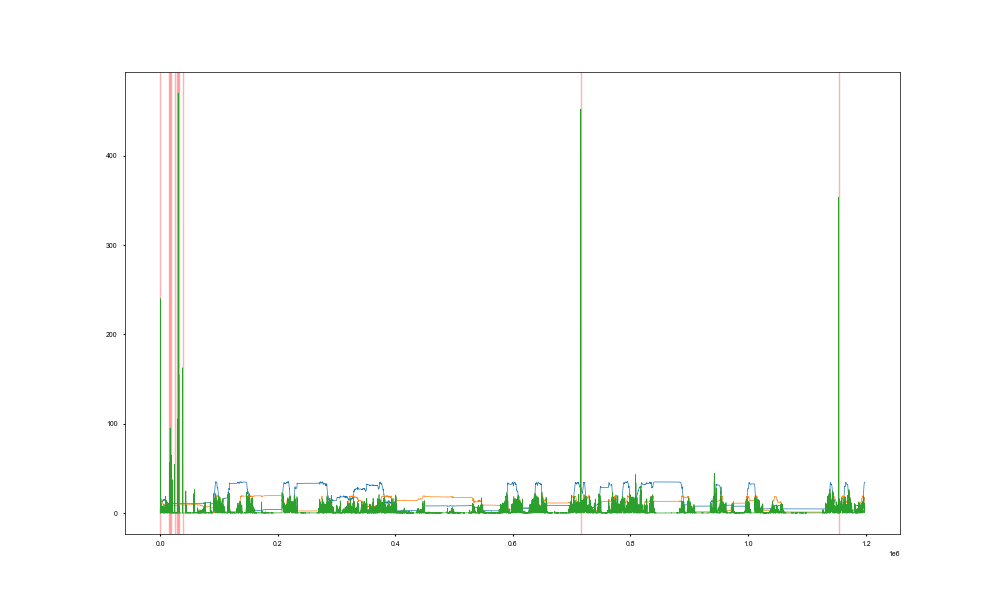

In [13]:
# detect epoch when speed pass threshold
speed_threshold = 50
remove_window = 5
epochs_outliers = detect_speed_epochs(speed, speed_threshold, min_duration=1)

fig, ax = plt.subplots(1, 1, figsize=(10, 6), sharex=True)
ax.plot(ts_neural, x_neural, label='Interpolated X Position', linewidth=0.5)
ax.plot(ts_neural, y_neural, label='Interpolated Y Position', linewidth=0.5)
ax.plot(ts_neural, speed, label='Speed (cm/s)', linewidth=0.5)

for start, end in epochs_outliers:
    start = ts_neural[start]
    end = ts_neural[end]
    
    ax.axvspan(start, end, color='red', alpha=0.3, label='Speed Outlier Epochs')

# set x_neural, y_neural, speed during these epochs to NaN, then interpolate to nearest values
for start, end in epochs_outliers:
    x_neural[start-remove_window:end+remove_window] = np.nan
    y_neural[start-remove_window:end+remove_window] = np.nan
    speed[start-remove_window:end+remove_window] = np.nan
x_neural = pd.Series(x_neural).interpolate(method='nearest').to_numpy()
y_neural = pd.Series(y_neural).interpolate(method='nearest').to_numpy()
speed = pd.Series(speed).interpolate(method='nearest').to_numpy()


In [14]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
from scipy.ndimage import center_of_mass

# -----------------------------------------------------------------------------
# ASSUMPTIONS:
# The following variables must be defined in your environment before running:
# ts_neural: array of timestamps
# x_neural: array of x positions
# y_neural: array of y positions
# speed: array of speeds
# traces: 2D array of neural traces (cells x time)
# refined_SS: list of simple-spike indices per cell
# all_CS_spikes: list of complex-spike indices per cell
# main_data_folder: string path to your output folder
# detect_speed_epochs: function (from your PC_2D_preprocess.py)
# mean_images: list of mean images for each session
# weights_all: list of weight arrays (ncell, height, width) for each session
# -----------------------------------------------------------------------------

# 1. Setup Speed Epochs
speed_threshold = 2  # Adjust as needed
speed_epochs = detect_speed_epochs(speed, speed_threshold, min_duration=0.5)

# 2. Prepare mean images with weight overlay and compute cell centers
num_sessions = len(mean_images)

# Process images: flip if height > width, overlay weights, get cell centers
processed_images = []
cell_centers_per_session = []  # List of lists: [[{cell_id, y, x}, ...], ...]

for i, (mean_img, weights) in enumerate(zip(mean_images, weights_all)):
    # Sum weights across all cells
    weight_sum = np.sum(weights, axis=0)
    
    # Compute center of mass for each cell's weight
    cell_centers = []
    for cell_idx in range(weights.shape[0]):
        cell_weight = weights[cell_idx]
        if np.nansum(cell_weight) > 0:
            cy, cx = center_of_mass(cell_weight)
            # Use 1-based cell numbering
            cell_centers.append({'cell_id': cell_idx + 1, 'y': cy, 'x': cx})
    
    # Flip if height > width
    if mean_img.shape[0] > mean_img.shape[1]:
        mean_img = np.transpose(mean_img)
        weight_sum = np.transpose(weight_sum)
        # Also flip the cell centers
        for c in cell_centers:
            c['y'], c['x'] = c['x'], c['y']
    
    processed_images.append((mean_img, weight_sum))
    cell_centers_per_session.append(cell_centers)

# 3. Create figure using domain-based positioning for full control
fig = go.Figure()

# Define layout regions
# Row 1 (top): Images - height 0.12 (from y=0.88 to y=1.0)
# Row 2 (middle): Traces - height 0.70 (from y=0.15 to y=0.85)  
# Row 3 (bottom): Position - height 0.12 (from y=0.0 to y=0.12)

image_y_bottom = 0.88
image_y_top = 1.0
traces_y_bottom = 0.13
traces_y_top = 0.87
position_y_bottom = 0.0
position_y_top = 0.12

# -----------------------------------------------------------------------------
# ROW 1: Mean Images with Weight Overlay (using domain-based axes)
# -----------------------------------------------------------------------------
for i, (mean_img, weight_sum) in enumerate(processed_images):
    # Normalize mean image to 0-255
    img_norm = ((mean_img - np.nanmin(mean_img)) / (np.nanmax(mean_img) - np.nanmin(mean_img)) * 255).astype(np.uint8)
    
    # Create RGB image (grayscale)
    img_rgb = np.stack([img_norm, img_norm, img_norm], axis=-1)
    
    # Normalize weight sum for overlay
    if np.nanmax(weight_sum) > 0:
        weight_norm = (weight_sum - np.nanmin(weight_sum)) / (np.nanmax(weight_sum) - np.nanmin(weight_sum))
    else:
        weight_norm = np.zeros_like(weight_sum)
    
    # Create red overlay
    overlay_strength = 0.6
    img_overlay = img_rgb.copy().astype(np.float32)
    img_overlay[:, :, 0] = np.clip(img_overlay[:, :, 0] + weight_norm * 255 * overlay_strength, 0, 255)
    img_overlay[:, :, 1] = np.clip(img_overlay[:, :, 1] * (1 - weight_norm * overlay_strength * 0.5), 0, 255)
    img_overlay[:, :, 2] = np.clip(img_overlay[:, :, 2] * (1 - weight_norm * overlay_strength * 0.5), 0, 255)
    img_overlay = img_overlay.astype(np.uint8)
    
    # Calculate x domain for this image
    x_start = i / num_sessions
    x_end = (i + 1) / num_sessions
    
    # Add image trace
    fig.add_trace(
        go.Image(z=img_overlay, name=f'Session {i+1}')
    )
    
    # Configure axes for this image
    xaxis_name = f'x{i+1}' if i > 0 else 'x'
    yaxis_name = f'y{i+1}' if i > 0 else 'y'
    
    fig.data[-1].update(xaxis=xaxis_name, yaxis=yaxis_name)
    
    # Add cell number annotations at cell centers (1-based)
    for cell_info in cell_centers_per_session[i]:
        fig.add_trace(
            go.Scatter(
                x=[cell_info['x']],
                y=[cell_info['y']],
                mode='text',
                text=[str(cell_info['cell_id'])],
                textfont=dict(color='cyan', size=10),
                showlegend=False,
                xaxis=xaxis_name,
                yaxis=yaxis_name
            )
        )

# -----------------------------------------------------------------------------
# ROW 2: Neural Traces & Spikes
# -----------------------------------------------------------------------------
num_cells = traces.shape[0]
traces_xaxis = f'x{num_sessions + 1}'
traces_yaxis = f'y{num_sessions + 1}'


def _spike_indices_for_plot(spk_like, n_time, trace_norm):
    if spk_like is None:
        return np.array([], dtype=np.int64)
    arr = np.asarray(spk_like)
    if arr.dtype == bool:
        idx = np.flatnonzero(arr)
    else:
        try:
            idx = arr.astype(np.int64, copy=False).reshape(-1)
        except Exception:
            return np.array([], dtype=np.int64)
    idx = idx[(idx >= 0) & (idx < n_time)]
    if idx.size == 0:
        return np.array([], dtype=np.int64)
    idx = np.unique(idx)
    valid = ~np.isnan(trace_norm[idx])
    return idx[valid]


for i in range(num_cells):
    trace = traces[i].squeeze()

    # NaN-safe Normalization
    t_min = np.nanmin(trace)
    t_max = np.nanmax(trace)

    if np.isnan(t_min) or np.isnan(t_max) or (t_max == t_min):
        trace_norm = np.full_like(trace, np.nan)
    else:
        trace_norm = (trace - t_min) / (t_max - t_min)

    # Use 1-based cell numbering in legend
    fig.add_trace(
        go.Scatter(
            x=ts_neural,
            y=trace_norm + i,
            mode='lines',
            name=f'Cell {i+1}',  # 1-based numbering
            line=dict(width=0.5),
            showlegend=True,
            xaxis=traces_xaxis,
            yaxis=traces_yaxis
        )
    )

    ss_like = refined_SS[i] if 'refined_SS' in globals() and i < len(refined_SS) else None
    cs_like = all_CS_spikes[i] if 'all_CS_spikes' in globals() and i < len(all_CS_spikes) else None

    ss_idx = _spike_indices_for_plot(ss_like, len(trace_norm), trace_norm)
    cs_idx = _spike_indices_for_plot(cs_like, len(trace_norm), trace_norm)

    if ss_idx.size > 0:
        fig.add_trace(
            go.Scatter(
                x=ts_neural[ss_idx],
                y=trace_norm[ss_idx] + i,
                mode='markers',
                name='Simple Spikes' if i == 0 else None,
                marker=dict(color='#1f77b4', size=2),
                showlegend=(i == 0),
                xaxis=traces_xaxis,
                yaxis=traces_yaxis
            )
        )

    if cs_idx.size > 0:
        fig.add_trace(
            go.Scatter(
                x=ts_neural[cs_idx],
                y=trace_norm[cs_idx] + i,
                mode='markers',
                name='Complex Spikes' if i == 0 else None,
                marker=dict(color='#ff7f0e', size=2),
                showlegend=(i == 0),
                xaxis=traces_xaxis,
                yaxis=traces_yaxis
            )
        )

# Add cell number annotations on the left side of traces plot
for i in range(num_cells):
    fig.add_annotation(
        x=ts_neural[0],  # Left edge of the plot
        y=i + 0.5,  # Center of each trace row
        text=f'{i+1}',  # 1-based cell number
        showarrow=False,
        font=dict(size=10, color='black'),
        xanchor='right',
        xshift=-5,
        xref=traces_xaxis,
        yref=traces_yaxis
    )

# -----------------------------------------------------------------------------
# ROW 3: Behavior (Position & Speed)
# -----------------------------------------------------------------------------
position_xaxis = f'x{num_sessions + 2}'
position_yaxis = f'y{num_sessions + 2}'

fig.add_trace(
    go.Scatter(x=ts_neural, y=x_neural, mode='lines', name='X Position', 
               line=dict(width=0.5), xaxis=position_xaxis, yaxis=position_yaxis)
)
fig.add_trace(
    go.Scatter(x=ts_neural, y=y_neural, mode='lines', name='Y Position', 
               line=dict(width=0.5), xaxis=position_xaxis, yaxis=position_yaxis)
)
fig.add_trace(
    go.Scatter(x=ts_neural, y=speed, mode='lines', name='Speed (cm/s)', 
               line=dict(width=0.5), xaxis=position_xaxis, yaxis=position_yaxis)
)

# -----------------------------------------------------------------------------
# LAYOUT: Define all axes domains
# -----------------------------------------------------------------------------
layout_dict = {
    'height': 1000,  # 1080p height minus browser UI
    'width': 1900,   # 1080p width minus scrollbar
    'title': 'Neural Data Plot',
    'showlegend': True,
    'legend': dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    'margin': dict(l=30, r=10, t=40, b=10),  # Minimal margins
    'paper_bgcolor': 'white',
    'plot_bgcolor': 'rgba(0,0,0,0)',  # Transparent background
}

# Add image axes (Row 1)
for i in range(num_sessions):
    x_start = i / num_sessions
    x_end = (i + 1) / num_sessions
    
    xaxis_key = f'xaxis{i+1}' if i > 0 else 'xaxis'
    yaxis_key = f'yaxis{i+1}' if i > 0 else 'yaxis'
    
    layout_dict[xaxis_key] = dict(
        domain=[x_start, x_end],
        showticklabels=False,
        showgrid=False,
        zeroline=False,
        showline=False,
        title=f'Session {i+1}'
    )
    layout_dict[yaxis_key] = dict(
        domain=[image_y_bottom, image_y_top],
        showticklabels=False,
        showgrid=False,
        zeroline=False,
        showline=False,
        scaleanchor=f'x{i+1}' if i > 0 else 'x',
        scaleratio=1
    )

# Traces axes (Row 2) - clean, no grid, no background
layout_dict[f'xaxis{num_sessions + 1}'] = dict(
    domain=[0, 1],
    anchor=f'y{num_sessions + 1}',
    showgrid=False,
    zeroline=False,
    showline=False,
    showticklabels=False
)
layout_dict[f'yaxis{num_sessions + 1}'] = dict(
    domain=[traces_y_bottom, traces_y_top],
    anchor=f'x{num_sessions + 1}',
    showgrid=False,
    zeroline=False,
    showline=False,
    showticklabels=False
)

# Position axes (Row 3) - clean, no grid, no background
layout_dict[f'xaxis{num_sessions + 2}'] = dict(
    domain=[0, 1],
    anchor=f'y{num_sessions + 2}',
    showgrid=False,
    zeroline=False,
    showline=False,
    showticklabels=False,
    matches=f'x{num_sessions + 1}'  # Link x-axis with traces
)
layout_dict[f'yaxis{num_sessions + 2}'] = dict(
    domain=[position_y_bottom, position_y_top],
    anchor=f'x{num_sessions + 2}',
    showgrid=False,
    zeroline=False,
    showline=False,
    showticklabels=False
)

# -----------------------------------------------------------------------------
# VISUALIZATION: Background Shapes for Speed Epochs
# -----------------------------------------------------------------------------
all_behavior_data = [x_neural, y_neural, speed]
behav_min = np.nanmin([np.nanmin(d) for d in all_behavior_data])
behav_max = np.nanmax([np.nanmax(d) for d in all_behavior_data])

traces_min = 0
traces_max = num_cells

shapes = []
if not np.isnan(behav_min) and not np.isnan(behav_max):
    for start_idx, end_idx in speed_epochs:
        start = ts_neural[start_idx]
        end = ts_neural[end_idx]
        
        # Shape for Traces subplot
        shapes.append(dict(
            type='rect',
            x0=start, x1=end,
            y0=traces_min, y1=traces_max,
            xref=f'x{num_sessions + 1}',
            yref=f'y{num_sessions + 1}',
            fillcolor='yellow',
            opacity=0.3,
            line=dict(width=0),
            layer='below'
        ))
        
        # Shape for Position subplot
        shapes.append(dict(
            type='rect',
            x0=start, x1=end,
            y0=behav_min, y1=behav_max,
            xref=f'x{num_sessions + 2}',
            yref=f'y{num_sessions + 2}',
            fillcolor='yellow',
            opacity=0.3,
            line=dict(width=0),
            layer='below'
        ))

layout_dict['shapes'] = shapes

# Apply layout
fig.update_layout(**layout_dict)

# Dummy trace for "Speed Epochs" legend entry
fig.add_trace(
    go.Scatter(x=[None], y=[None], mode='markers', 
               marker=dict(symbol='square', color='yellow', opacity=0.3, size=10),
               name='Speed Epochs',
               xaxis=position_xaxis, yaxis=position_yaxis)
)

# Save to HTML
output_file = os.path.join(main_data_folder, 'neural_data_plot.html')
fig.write_html(output_file)
print(f"Plot saved to {output_file}")
subprocess.run(["open", output_file])

Plot saved to /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce50/2025-03-17_pAce50_PRL/Awake/neural_data_plot.html


CompletedProcess(args=['open', '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce50/2025-03-17_pAce50_PRL/Awake/neural_data_plot.html'], returncode=0)

# Optional: Make head direction annotated video
Run locally (next cell) or on the cluster (cells after).

In [55]:
for data_folder in subfolders:
    df = read_DLC_csv_file(data_folder)
    df_refined, _, _, _ = refine_headpositions(df, data_folder=data_folder,thr_likelihood_head=0.6, thr_likelihood_nose=0.6, filter_kernel_size=1, short_gap_max_frames=5, interpolate_remaining_nan=False, include_body=False)
    video_file = glob.glob(os.path.join(data_folder, '*.avi'))[0]
    make_anotated_behav_video(video_file, df_refined)


Using filtered DLC file: Flir-11262025134541-0000DLC_Resnet50_TopViewMouse_MidlineDec11shuffle1_snapshot_080_filtered_with_headdir.csv
Frames with no valid best position: 1216/12000 (10.1%)
Frames with no valid second position: 1568/12000 (13.1%)
Video frames: 12000, Tracking frames: 12000


KeyboardInterrupt: 

### Submit annotated video job to cluster

In [42]:
import paramiko
import re

CLUSTER_HOST = 'loginserver.elsc.huji.ac.il'
USERNAME = 'qixin.yang'
SSH_KEY_PATH = os.path.expanduser('~/.ssh/id_rsa')

PIPELINE_WORKDIR = '/ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4'
sh_script = '/ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/utils/run_python_job.sh'
LOG_DIR = f"{PIPELINE_WORKDIR}/logs"

ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
kwargs = {}
if SSH_KEY_PATH and os.path.exists(SSH_KEY_PATH):
    kwargs['key_filename'] = SSH_KEY_PATH
ssh.connect(CLUSTER_HOST, username=USERNAME, **kwargs)
print('[INFO] Connected to cluster.')

[INFO] Connected to cluster.


In [43]:
# Submit annotated video jobs to cluster (one per subfolder)
python_script = 'utils/make_annotated_video.py'
JOB_NAME = 'annotated_video'

# Convert local paths to cluster paths
subfolders_cluster = [sf.replace('/Volumes/adam-lab', '/ems/elsc-labs/adam-y') for sf in subfolders]

# Ensure log dir exists
full_cmd = f"bash -l -c 'mkdir -p {LOG_DIR}'"
ssh.exec_command(full_cmd)

job_ids = []
for sf_cluster in subfolders_cluster:
    cmd = (
        f"sbatch --job-name {JOB_NAME} --mem=16G -c 4 -t 2:00:00 "
        f"--chdir {PIPELINE_WORKDIR} "
        f"--output {LOG_DIR}/%x_%j.out --error {LOG_DIR}/%x_%j.err "
        f"{sh_script} {PIPELINE_WORKDIR} {python_script} "
        f"{sf_cluster} "
        f"--thr-head 0.6 --thr-nose 0.6 --filter-kernel 1 "
        f"--short-gap 5"
    )
    full_cmd = f"bash -l -c '{cmd}'"
    stdin, stdout, stderr = ssh.exec_command(full_cmd)
    output = stdout.read().decode().strip()
    error = stderr.read().decode().strip()

    if error and 'Submitted' not in output:
        print(f"[ERROR] {sf_cluster}: {error}")
    else:
        print(f"[INFO] {output}")
        match = re.search(r'Submitted batch job (\d+)', output)
        if match:
            job_ids.append(match.group(1))

LOG_DIR_LOCAL = LOG_DIR.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
print(f"\nSubmitted {len(job_ids)} jobs: {job_ids}")
print(f"Logs: {LOG_DIR_LOCAL}")

[INFO] Submitted batch job 17432687
[INFO] Submitted batch job 17432688

Submitted 2 jobs: ['17432687', '17432688']
Logs: /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/logs


# Optional, make behavior + neural activity videos 

In [69]:
from utils.demo_video_with_neural import make_demo_video
import os

data_folder = subfolders[0]
behav_vid = sorted(f for f in os.listdir(data_folder) if f.endswith('.mp4'))
#behav_vid = glob.glob(os.path.join(data_folder, '*.avi'))

print(f"Found file: {behav_vid}")

Found file: ['Flir-11262025134541-0000DLC_Resnet50_TopViewMouse_MidlineDec11shuffle1_snapshot_080_filtered_p50_labeled.mp4', 'Flir-11262025134541-0000DLC_Resnet50_TopViewMouse_MidlineDec11shuffle1_snapshot_080_p50_labeled.mp4', 'output_with_head_direction.mp4', 'output_with_head_direction2.mp4', 'place_cell_activity_video.mp4']


In [70]:
make_demo_video(
    data_folder=data_folder,
    cells_display=[0, 2, 3, 4],
    behavior_video_path=os.path.join(data_folder, behav_vid[0]),
    output_fps=20, neural_step=25,
    max_frames=100
)


Loaded aligned data from /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake/2-good/aligned_data.pkl
ts_neural range: 3847.3 - 601867.3 ms, len=298894
ts_behav range: 3867.7 - 601817.7 ms, len=11960
frames_behav range: 39 - 11998, len=11960
Reading video from: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake/2-good/Flir-11262025134541-0000DLC_Resnet50_TopViewMouse_MidlineDec11shuffle1_snapshot_080_filtered_p50_labeled.mp4
behav_video shape: (12000, 842, 1364)
Loaded boundary box: x=[43, 1301], y=[42, 741]
Generating video... Output: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake/2-good/place_cell_activity_video.mp4


Rendering frames:   0%|          | 0/100 [00:00<?, ?it/s]

  frame 0: neural_ind=0, behav_ind=0, frame_behav_temp=39, pixel_mean=107.3


Rendering frames:   1%|          | 1/100 [00:00<00:18,  5.39it/s]

  frame 1: neural_ind=25, behav_ind=1, frame_behav_temp=40, pixel_mean=107.4


...

Rendering frames:   4%|▍         | 4/100 [00:00<00:14,  6.42it/s]

  frame 4: neural_ind=100, behav_ind=4, frame_behav_temp=43, pixel_mean=107.5


Rendering frames: 100%|██████████| 100/100 [00:14<00:00,  7.09it/s]


Video saved to: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake/2-good/place_cell_activity_video.mp4


'/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake/2-good/place_cell_activity_video.mp4'

## Submit demo video jobs to cluster

In [78]:
import paramiko
import re

CLUSTER_HOST = 'loginserver.elsc.huji.ac.il'
USERNAME = 'qixin.yang'
SSH_KEY_PATH = os.path.expanduser('~/.ssh/id_rsa')

PIPELINE_WORKDIR = '/ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4'
sh_script = '/ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/utils/run_python_job.sh'
LOG_DIR = f"{PIPELINE_WORKDIR}/logs"

ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
kwargs = {}
if SSH_KEY_PATH and os.path.exists(SSH_KEY_PATH):
    kwargs['key_filename'] = SSH_KEY_PATH
ssh.connect(CLUSTER_HOST, username=USERNAME, **kwargs)
print('[INFO] Connected to cluster.')

[INFO] Connected to cluster.


In [79]:
# Upload Python files to cluster code directory
import shutil

LOCAL_UTILS = os.path.join(parent_dir, 'utils')
REMOTE_UTILS = '/Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils'

files_to_sync = [
    'demo_video_with_neural.py',
    'make_demo_video_job.py',
    'make_annotated_video.py',
    'preprocess_neural.py',
    'preprocess_behavior.py',
]

for fname in files_to_sync:
    src = os.path.join(LOCAL_UTILS, fname)
    dst = os.path.join(REMOTE_UTILS, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"  {fname} -> OK")
    else:
        print(f"  {fname} -> SKIP (not found locally)")
print("Done.")

  demo_video_with_neural.py -> OK
  make_demo_video_job.py -> OK
  make_annotated_video.py -> OK
  preprocess_neural.py -> OK
  preprocess_behavior.py -> OK
Done.


In [80]:
# Submit demo video jobs to cluster (one per subfolder)
python_script = 'utils/make_demo_video_job.py'
JOB_NAME = 'demo_video'
CONDA_ENV = 'caiman'  # Change to a newer env if pickle loading fails (numpy version mismatch)

# --- Tunable parameters ---
cells_display = [0, 2, 3, 4] # pAce47
#cells_display = [0, 1, 3, 4, 5, 6] # pAce38
output_fps = 20
neural_step = 25
# --------------------------

subfolders_cluster = [sf.replace('/Volumes/adam-lab', '/ems/elsc-labs/adam-y') for sf in subfolders]

full_cmd = f"bash -l -c 'mkdir -p {LOG_DIR}'"
ssh.exec_command(full_cmd)

cells_str = ' '.join(str(c) for c in cells_display)

job_ids = []
for sf_cluster in subfolders_cluster:
    # Resolve the actual .avi filename on the cluster
    find_cmd = f"bash -l -c 'ls {sf_cluster}/*.avi 2>/dev/null | head -1'"
    _, stdout_avi, _ = ssh.exec_command(find_cmd)
    avi_path = stdout_avi.read().decode().strip()
    if not avi_path:
        print(f"[SKIP] No .avi found in {sf_cluster}")
        continue

    cmd = (
        f"sbatch --job-name {JOB_NAME} --mem=32G -c 4 -t 4:00:00 "
        f"--export=ALL,CONDA_ENV_NAME={CONDA_ENV} "
        f"--chdir {PIPELINE_WORKDIR} "
        f"--output {LOG_DIR}/%x_%j.out --error {LOG_DIR}/%x_%j.err "
        f"{sh_script} {PIPELINE_WORKDIR} {python_script} "
        f"{sf_cluster} {avi_path} "
        f"--cells {cells_str} "
        f"--output-fps {output_fps} --neural-step {neural_step}"
    )
    full_cmd = f"bash -l -c '{cmd}'"
    stdin, stdout, stderr = ssh.exec_command(full_cmd)
    output = stdout.read().decode().strip()
    error = stderr.read().decode().strip()

    if error and 'Submitted' not in output:
        print(f"[ERROR] {sf_cluster}: {error}")
    else:
        print(f"[INFO] {output}")
        match = re.search(r'Submitted batch job (\d+)', output)
        if match:
            job_ids.append(match.group(1))

LOG_DIR_LOCAL = LOG_DIR.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
print(f"\nSubmitted {len(job_ids)} jobs: {job_ids}")
print(f"Logs: {LOG_DIR_LOCAL}")

[INFO] Submitted batch job 17988009
[INFO] Submitted batch job 17988010

Submitted 2 jobs: ['17988009', '17988010']
Logs: /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/logs
